Install Required Libraries

In [5]:
!pip install pandas numpy scikit-learn joblib matplotlib seaborn 

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib


Load Dataset

In [2]:
df = pd.read_csv("loan_dataset_20000.csv")


In [3]:
df.columns

Index(['age', 'gender', 'marital_status', 'education_level', 'annual_income',
       'monthly_income', 'employment_status', 'debt_to_income_ratio',
       'credit_score', 'loan_amount', 'loan_purpose', 'interest_rate',
       'loan_term', 'installment', 'grade_subgrade', 'num_of_open_accounts',
       'total_credit_limit', 'current_balance', 'delinquency_history',
       'public_records', 'num_of_delinquencies', 'loan_paid_back'],
      dtype='str')

Select ONLY Required Inputs & Output

In [4]:
input_features = [
    "age",
    "gender",
    "marital_status",
    "education_level",
    "annual_income",
    "employment_status",
    "debt_to_income_ratio",
    "credit_score",
    "loan_amount",
    "loan_purpose",
    "loan_term",
    "num_of_open_accounts",
    "total_credit_limit",
    "delinquency_history"
]

target = "loan_paid_back"

df = df[input_features + [target]]


Display Dataset After Column Selection

In [5]:
df.head()

,age,gender,marital_status,education_level,annual_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,loan_purpose,loan_term,num_of_open_accounts,total_credit_limit,delinquency_history,loan_paid_back
0,59,Male,Married,Master's,24240.19,Employed,0.074,743,17173.72,Car,36,7,40833.47,1,1
1,72,Female,Married,Bachelor's,20172.98,Employed,0.219,531,22663.89,Debt consolidation,60,5,27968.01,1,1
2,49,Female,Single,High School,26181.80,Employed,0.234,779,3631.36,Business,60,2,15502.25,0,1
3,35,Female,Single,High School,11873.84,Employed,0.264,809,14939.23,Other,36,7,18157.79,4,1
4,63,Other,Single,Other,25326.44,Employed,0.260,663,16551.71,Car,60,1,17467.56,2,1


Dataset Information

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  str    
 2   marital_status        20000 non-null  str    
 3   education_level       20000 non-null  str    
 4   annual_income         20000 non-null  float64
 5   employment_status     20000 non-null  str    
 6   debt_to_income_ratio  20000 non-null  float64
 7   credit_score          20000 non-null  int64  
 8   loan_amount           20000 non-null  float64
 9   loan_purpose          20000 non-null  str    
 10  loan_term             20000 non-null  int64  
 11  num_of_open_accounts  20000 non-null  int64  
 12  total_credit_limit    20000 non-null  float64
 13  delinquency_history   20000 non-null  int64  
 14  loan_paid_back        20000 non-null  int64  
dtypes: float64(4), int64(6), str(5

Check Missing Values

In [7]:
df.isnull().sum()

age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
loan_term               0
num_of_open_accounts    0
total_credit_limit      0
delinquency_history     0
loan_paid_back          0
dtype: int64

Remove Missing Values

In [8]:
df.dropna(inplace=True)

Check Duplicate Rows

In [9]:
df.duplicated().sum()

np.int64(0)

Remove Duplicate Rows

In [10]:
df.drop_duplicates(inplace=True)

Check Noise / Outliers (Example)

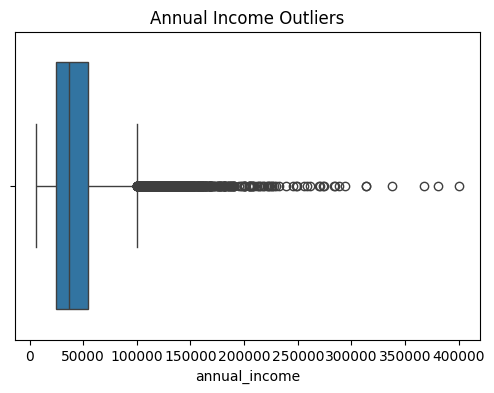

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["annual_income"])
plt.title("Annual Income Outliers")
plt.show()

Encode Categorical Columns

In [12]:
categorical_columns = [
    "gender",
    "marital_status",
    "education_level",
    "employment_status",
    "loan_purpose"
]

label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
